¡Hola Manuel! Espero estés bien.

Mi nombre es **Gina Buvoli**. Un gusto conocerte, seré tu revisora en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierta a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis. Continúa aplicando estas buenas prácticas en futuras secciones.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
El código es correcto, pero hay una recomendación de mejora. No bloquea la aprobación, pero vale la pena ajustarlo.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
Aquí hay un error que es necesario corregir para aprobar. Por favor revisa este punto antes de volver a enviar.
</div>

---

En cada revisión recibirás un **Comentario General** que resume los aspectos positivos, las áreas de mejora y los próximos pasos.

También puedes responderme copiando el siguiente bloque si tienes alguna duda:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante [#° iteración]</b> <a class="tocSkip"></a>

Aquí puedes escribir tu respuesta o pregunta.
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola Manuel!

Este es un proyecto muy sólido y con un nivel de pensamiento crítico destacable. Los diagnósticos de variables son detallados y ya anticipan hipótesis de análisis (como la posible relación mecánica entre <code>compras_mes</code> e <code>ingreso_anual</code>), el scatterplot general está correctamente justificado como necesario, el Punto-biserial cubre cuatro combinaciones relevantes con interpretación de significancia estadística, la V de Cramér evalúa cinco pares con conclusiones claras, y los hallazgos demuestran comprensión madura de las limitaciones del análisis correlacional — en especial la reflexión sobre multicolinealidad y la implicación de negocio de <code>gasto_publicidad_dirigida</code> como palanca accionable.

El proyecto queda aprobado. Hay una recomendación importante que te pido revisar para tu portafolio: en la Sección 4 afirmas un valor de Spearman para <code>compras_mes vs ingreso_anual</code> que nunca calculaste en el código — ver el comentario correspondiente para más detalle. También hay dos ajustes menores de estilo (ver comentarios de Sección 3 y 5).

Felicitaciones por el trabajo.

Saludos,
Gina Buvoli
</div>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [122]:
# Importar librerías
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr

### Cargar Dataset

In [123]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [124]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
<b>Éxito ✅</b><br>
Buena exploración inicial. Cargaste el dataset correctamente, validaste tipos y nulos con <code>df.info()</code>, y la descripción de columnas es clara y bien contextualizada.
</div>

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`


La mayoría de estas variables presentan tipos de datos adecuados.  
La columna nivel_ingreso de poco nos servira, ya que solo nos interesa saber cuanto gana el cliente para saber si esto tiene alguna relación con su comportamiento de compra. Por otro lado la de edad debemos cambiarla a int64


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [125]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype("int64")

In [126]:
# verificar cambios
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


#### Explorar variables numéricas

In [127]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — Aqui los datos parecen estar muy bien distribuidos y sin sesgos, ya que podemos ver una media de 38.26 y una mediana de 38, por otro lado en cuanto a los outliers poedemos ver que ahy valores extremos hacia el maximo de edad, pero posibles.
- `nivel_ingreso` — Aparentemente tambien sin sesos aunque al ser el ingreso estimado una variable continua muy dispersa requiere un analisis muy profundo.
- `visitas_mes, Compras mes` — Parecen tampoco tener sesgos al menos tan grandes que comprometan el analisis y pueden ser una buena correlación a analizar para detectar si hay causalidad o si estan fuertemente relacionadas.
- `gasto_publicidad_dirigida` — no esta sesgada a mi primera vista, vale la pena verla por segmentación para ver si tiene algun impacto relacionado con las compras del mes y determinar si la publicidad influye en la compra de los productos.
- `satisfacción` — Poca dispersión debido que es calificada del 1-5, esta nos puede ser bastante utilpara analizar una correlación que determine si la calificación que nos dan puede influir en la cantidad de visitas al mes.
- `ingreso_anual` — Distribución sesgada que muy probablemente requerira de una segmentación para determinar si hay un posible relación entre el ingreso anual y la cantidad de compras al mes.

#### Explorar variables binarias

In [128]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[["miembro_premium", "abandono"]].nunique()

miembro_premium    2
abandono           2
dtype: int64

In [129]:
tasa_de_abandono = df.groupby("miembro_premium")["abandono"].mean()
tasa_de_abandono

miembro_premium
0    0.168074
1    0.043562
Name: abandono, dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — Los que no estan en premium parecen tener una mayor tasa de abandono, esto puede deberse principalmente a que los beneficios de plan premium tengan un buen enganche, sin embargo esto requiere un analisis aun mas profundo.
- `abandono` — La tasa de abandono en ambos planes es baja-moderada, aunque si es preocupante en los usuarios que no son premium ya que cerca del 17% abandonan.

#### Explorar variables categóricas

In [130]:
# Verificar el número de valores únicos por variable categórica

print(df["tipo_dispositivo"].nunique())
print(df["region"].nunique())

3
4


In [131]:
Q_total_compras = df["compras_mes"].sum()

In [132]:
# Explorar variables categóricas y cómo se distribuyen
# Porcentaje de ventas por región y por tipo de dispositivo
print(df.groupby("region")["compras_mes"].sum() / Q_total_compras)
print(df.groupby("tipo_dispositivo")["compras_mes"].sum() / Q_total_compras)

region
este     0.206443
norte    0.294579
oeste    0.247721
sur      0.251257
Name: compras_mes, dtype: float64
tipo_dispositivo
escritorio    0.247002
móvil         0.653423
tablet        0.099575
Name: compras_mes, dtype: float64


In [148]:
# Promedio de cantidad de compras por región y por tipo de dispositivo
print(df.groupby("region")["compras_mes"].mean())
print(df.groupby("tipo_dispositivo")["compras_mes"].mean())

region
este     1.217335
norte    1.212969
oeste    1.176640
sur      1.220344
Name: compras_mes, dtype: float64
tipo_dispositivo
escritorio    1.201613
móvil         1.204420
tablet        1.232558
Name: compras_mes, dtype: float64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — El dispositivo movil es notoramiente mas vendido, cosa que es de esperarse puesto que la mayoria de la población necesita un dispositivo movil.
- `region` — Los datos estan muy bien distribuidos por lo que no hay suficiente evidencia a primera vista para afirmar que la cantidad de ventas dependa de la región.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
<b>Éxito ✅</b><br>
Excelente sección de preparación. Los diagnósticos de variables numéricas ya anticipan hipótesis de análisis pertinentes (por ejemplo, la posible relación entre satisfacción y visitas, o la necesidad de segmentar <code>ingreso_anual</code>). El diagnóstico de variables binarias incluye una cifra concreta y relevante (17% de abandono en no premium), y el de categóricas está bien fundamentado. Los supuestos justifican correctamente cada coeficiente.
</div>

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

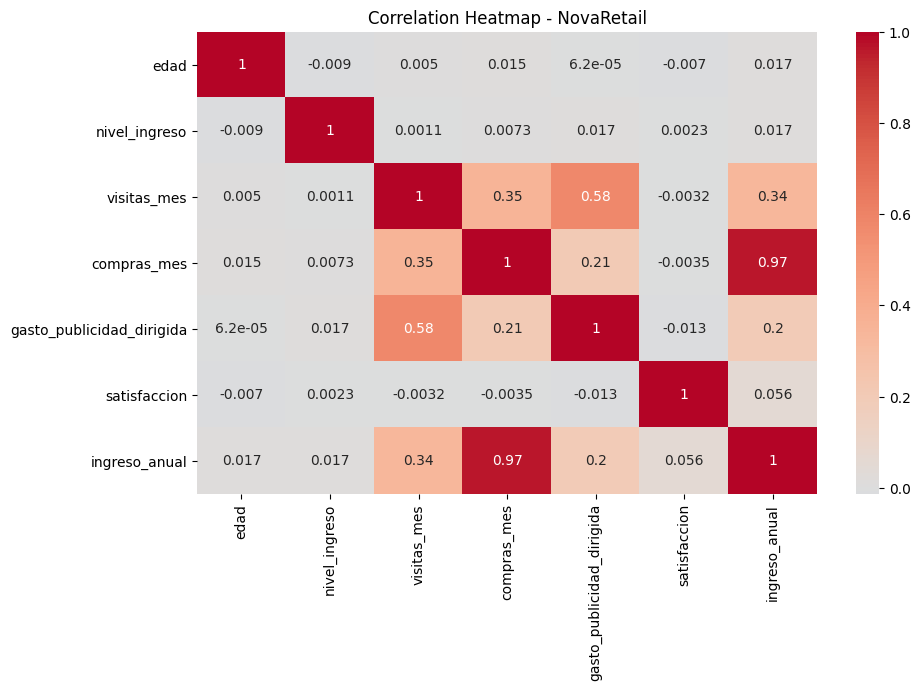

In [134]:
# Visualizar la matriz de correlación para identificar relaciones
cols_n = df[["edad", "nivel_ingreso", "visitas_mes", "compras_mes", "gasto_publicidad_dirigida", "satisfaccion", "ingreso_anual"]]
corr = cols_n.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaRetail")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa que visitas_mes se relaciona moderadamente con publicidad_dirigida (0.58) y débilmente con compras_mes e ingreso_anual (~0.34-0.35) únicas relaciones de negocio con algo de relación, ya las dema tienen relación bastante debil o practicamente nula.


Observaciones respecto a `ingreso_anual`  
- Presenta demasiado ruido en su relación con `compras_mes` ya que tienen correlación casi directa y esta levanta sospechas, hay que analizarla mas a fondo antes de terminar que una sea la causa de la otra.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

En este caso no solo es recomendable hacerlo si no que es necesario para poder investigar a que se debe que la correlación compas_mes - ingreso_anual es casi perfecta.

### Scatterplot para pares clave

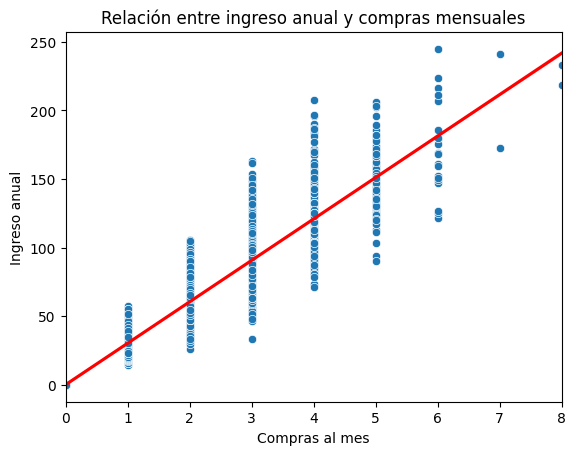

In [135]:

# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=cols_n, x="compras_mes", y="ingreso_anual")
sns.regplot(data=df, x='compras_mes', y='ingreso_anual',
    scatter=False, color='red')

plt.title("Relación entre ingreso anual y compras mensuales")
plt.xlabel("Compras al mes")
plt.ylabel("Ingreso anual")
plt.show()


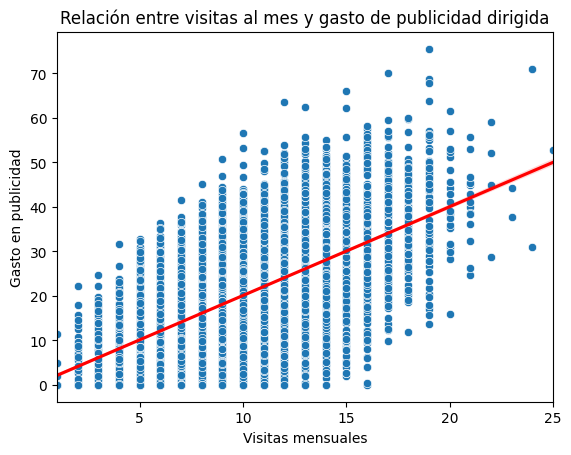

In [136]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=cols_n, x="visitas_mes", y="gasto_publicidad_dirigida")
sns.regplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida',
    scatter=False, color='red')

plt.title("Relación entre visitas al mes y gasto de publicidad dirigida")
plt.xlabel("Visitas mensuales")
plt.ylabel("Gasto en publicidad")
plt.show()


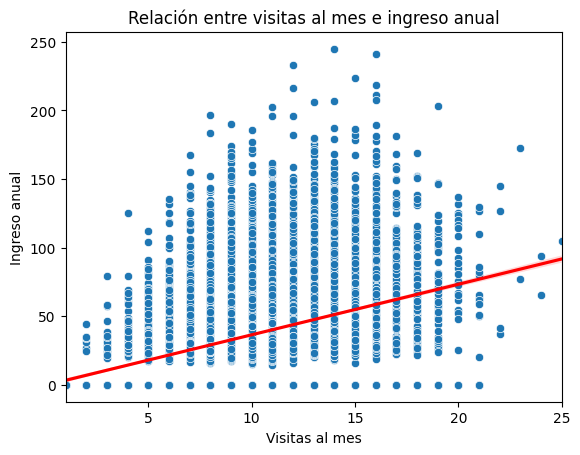

In [137]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=cols_n, x="visitas_mes", y="ingreso_anual")
sns.regplot(data=df, x='visitas_mes', y='ingreso_anual',
    scatter=False, color='red')

plt.title("Relación entre visitas al mes e ingreso anual")
plt.xlabel("Visitas al mes")
plt.ylabel("Ingreso anual")
plt.show()


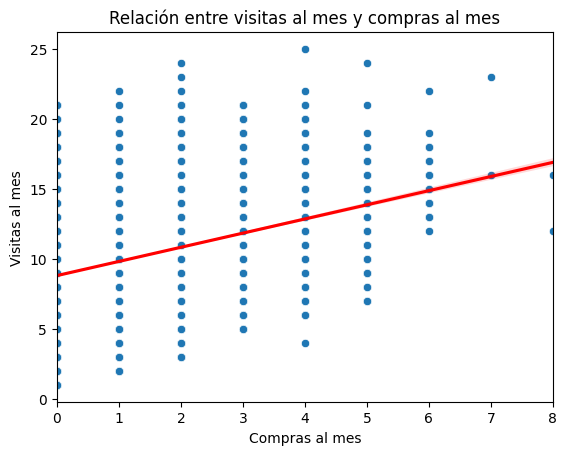

In [138]:
sns.scatterplot(data=cols_n, x="compras_mes", y="visitas_mes")
sns.regplot(data=df, x='compras_mes', y='visitas_mes',
    scatter=False, color='red')

plt.title("Relación entre visitas al mes y compras al mes")
plt.xlabel("Compras al mes")
plt.ylabel("Visitas al mes")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual:**
La relación es positiva y muy consistente, con dispersión baja-media alrededor de la recta. No se observan outliers relevantes, y la colinealidad es fuerte (r=0.97), lo cual amerita cuidado si ambas variables se incluyen juntas en un mismo modelo predictivo por el riesgo de multicolinealidad.

**visitas_mes vs gasto_publicidad_dirigida**
La dirección es positiva, pero con dispersión media-alta, lo que indica que la relación es real pero bastante ruidosa. No hay outliers marcados, solo variabilidad natural, y la colinealidad es moderada (r=0.58), suficiente para considerarla relevante pero no dominante.

**visitas_mes vs compras_mes**
La dirección es positiva pero leve, con dispersión alta en cada nivel de compras. No hay outliers extremos que distorsionen el patrón, y la colinealidad es baja (r=0.35), lo que confirma que ambas variables no están fuertemente ligadas de forma lineal.

**visitas_mes vs ingreso_anual**
La dirección es positiva pero débil, con dispersión alta en todos los niveles de visitas. Hay algunos puntos que se alejan del patrón general, como clientes con pocas visitas (3-4) pero ingreso relativamente alto (~130), aunque no son outliers extremos, solo ruido propio de una relación débil. La colinealidad es baja (r=0.34), consistente con el heatmap.


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
<b>Atención ⚠️</b><br>
Muy buen trabajo en esta sección: las observaciones del heatmap identifican correctamente las relaciones relevantes con valores específicos, y la justificación del scatterplot general como <i>necesario</i> (no solo recomendable) para investigar la relación <code>compras_mes-ingreso_anual</code> muestra buen criterio analítico. Los cuatro scatterplots cubren los pares más informativos con observaciones detalladas. Un ajuste de terminología: usas "colinealidad" para describir la fuerza de cada correlación (ej. "colinealidad fuerte (r=0.97)"). Ese término corresponde a un problema entre variables predictoras en modelos de regresión, no es el nombre de una correlación fuerte en un análisis descriptivo. Te recomiendo reemplazarlo por "correlación" o "relación lineal" en estas observaciones (aunque el uso que le das más adelante, en el Hallazgo 1, sobre multicolinealidad en un futuro modelo predictivo, sí es correcto).
</div>

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [43]:
# Calcular correlación entre variables relevantes
df['compras_mes'].corr(df['ingreso_anual'], method='pearson')

0.9671485435708564

In [44]:
df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='pearson')

0.1974827018234103

In [45]:
df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='spearman')

0.18499874477115502

In [46]:
# Calcular correlación entre variables relevantes
df['gasto_publicidad_dirigida'].corr(df["visitas_mes"], method='pearson')

0.5789472719412827

In [47]:
df['gasto_publicidad_dirigida'].corr(df["visitas_mes"], method='spearman')

0.5592673242622609

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación


- **Correlación compras_mes vs ingreso_anual**

La correlación de Pearson es de 0.967 y la de Spearman de 0.967, valores prácticamente idénticos. La dirección de la relación es positiva, es decir, a mayor ingreso anual, mayores son las compras mensuales. La magnitud es muy fuerte, ya que ambos coeficientes están muy cerca de 1. Como Pearson y Spearman coinciden, esto indica que la relación es tanto lineal como monótona, lo que sugiere una asociación consistente y no distorsionada por valores atípicos.


- **Correlación visitas_mes vs ingreso_anual**

Ambos coeficientes son muy similares (diferencia de apenas 0.02), lo cual confirma que la relación es efectivamente lineal/monótona y que Pearson es el método adecuado para reportar aquí — no hay evidencia de una relación no lineal oculta que Spearman esté capturando mejor.
  
La dirección es positiva y la magnitud es moderada en ambos casos. Esto respalda lo que ya viste en el scatterplot: a mayor gasto en publicidad dirigida, más visitas mensuales, con una relación real pero con dispersión considerable (no es una relación tan fuerte como compras_mes-ingreso_anual, pero tampoco es despreciable).




- **Correlación visitas_mes vs gasto_publicidad_dirigida**


La correlación de Pearson es de 0.579 y la de Spearman de 0.559, valores bastante cercanos entre sí. La dirección de la relación es positiva y la magnitud es moderada, ni débil ni fuerte. El hecho de que ambos coeficientes sean similares indica que la relación es principalmente lineal, sin señales fuertes de no linealidad. Esto sugiere que existe una relación notable entre ambas variables, pero no determinante: el gasto en publicidad dirigida explica parte del comportamiento de las visitas mensuales, aunque otros factores también influyen.



### Punto-biserial

In [57]:
# Calcular correlación entre variables relevantes
print("miembro_premium-compras_mes :", pointbiserialr(df["miembro_premium"], df["compras_mes"]))
print()
print("miembro_premium-ingreso_anual :", pointbiserialr(df["miembro_premium"], df["ingreso_anual"]))
print()
print("Abandono-satisfaccion :", pointbiserialr(df["abandono"], df["satisfaccion"]))
print()
print("Abandono-visitas_mes :", pointbiserialr(df["abandono"], df["visitas_mes"]))

miembro_premium-compras_mes : SignificanceResult(statistic=0.003430536967706773, pvalue=0.674398174411559)

miembro_premium-ingreso_anual : SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

Abandono-satisfaccion : SignificanceResult(statistic=-0.02383256067380403, pvalue=0.003510976893362289)

Abandono-visitas_mes : SignificanceResult(statistic=-0.008942702975011398, pvalue=0.273436216712885)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**Miembro_premium vs Compras_mes**
- Coeficiente prácticamente nulo (0.0034) y p-value de 0.674, muy por encima del umbral típico de 0.05. Esto significa que no hay relación real ni estadísticamente significativa entre ser miembro premium y la cantidad de compras al mes. Ser premium no está asociado con comprar más seguido.
  
**Miembro_premium vs Ingreso_anual**
- Aquí está lo interesante — el coeficiente es bajo (0.093, técnicamente débil), pero el p-value es extremadamente pequeño, lo que indica que esta relación sí es estadísticamente significativa, aunque de magnitud débil. Es decir: hay evidencia sólida de que existe una asociación entre ser premium y tener mayor ingreso anual, pero esa asociación es débil en términos prácticos.

**Abandono vs Satisfaccion**
- Coeficiente negativo pequeño (-0.024) pero significativo (p=0.0035). La dirección tiene sentido de negocio (a menor satisfacción, más probabilidad de abandono), y aunque la relación es débil en magnitud, sí es estadísticamente confiable.

**Abandono vs Visitas_mes**
- Coeficiente muy pequeño (-0.0089) y p-value alto (0.273), por lo que no hay evidencia de relación significativa entre visitas mensuales y abandono.

### V de Cramér

In [98]:
# Función para calcular V de Cramér
tabla = pd.crosstab(
    df["region"],
    df["tipo_dispositivo"])

tabla1 = pd.crosstab(
    df["tipo_dispositivo"],
    df["miembro_premium"])

tabla2 = pd.crosstab(
    df["tipo_dispositivo"],
    df["abandono"])

tabla3 = pd.crosstab(
    df["region"],
    df["miembro_premium"])    

tabla4 = pd.crosstab(
    df["region"],
    df["abandono"])


In [110]:
# Aplicar V de Cramér en variables relevantes
chi2_0, p, dof, expected = chi2_contingency(tabla)

chi2_1, p, dof, expected = chi2_contingency(tabla1)

chi2_2, p, dof, expected = chi2_contingency(tabla2)

chi2_3, p, dof, expected = chi2_contingency(tabla3)

chi2_4, p, dof, expected = chi2_contingency(tabla4)

In [111]:
chi2_0

4.596697852095489

In [112]:
chi2_1

5.836391466827039

In [113]:
chi2_2

0.7873917659380356

In [114]:
chi2_3

2.371651182308931

In [115]:
chi2_4

3.5711402670640715

In [116]:
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2_0 / (n * (min(tabla.shape) -1)))
cramers_v

0.012378338407739397

In [117]:

n1 = tabla1.sum().sum()
cramers_v1 = np.sqrt(chi2_1 / (n1 * (min(tabla1.shape) -1)))
cramers_v1


0.01972543445542166

In [118]:
n2 = tabla2.sum().sum()
cramers_v2 = np.sqrt(chi2_2 / (n2 * (min(tabla2.shape) -1)))
cramers_v2

0.007245190431994803

In [119]:
n3 = tabla3.sum().sum()
cramers_v3 = np.sqrt(chi2_3 / (n3 * (min(tabla3.shape) -1)))
cramers_v3

0.012574183027958334

In [120]:
n4 = tabla4.sum().sum()
cramers_v4 = np.sqrt(chi2_4 / (n4 * (min(tabla4.shape) -1)))
cramers_v4

0.015429712175030079

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

**Region vs Tipo_dispositivo (V=0.0124):** Prácticamente nulo. No hay asociación real entre la región del cliente y el tipo de dispositivo que usa.

**Tipo_dispositivo vs Miembro_premium (V=0.0197):** También prácticamente nulo, el valor más alto de los cinco, pero sigue siendo insignificante en términos prácticos. No hay evidencia de que el tipo de dispositivo esté relacionado con ser miembro premium.

**Tipo_dispositivo vs Abandono (V=0.0072):** El más bajo de todos, esencialmente cero. No hay ninguna asociación entre el dispositivo usado y la probabilidad de abandono.

**Region vs Miembro_premium (V=0.0126):** Prácticamente nulo, sin asociación relevante entre la región y la membresía premium.

**Region vs Abandono (V=0.0154):** Igualmente cercano a cero, sin asociación real entre región y abandono.


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
<b>Atención ⚠️</b><br>
El Punto-biserial es excelente: cubre cuatro combinaciones relevantes (incluyendo <code>ingreso_anual</code> y variables como <code>satisfaccion</code>), con interpretación correcta de significancia estadística en cada caso — la distinción entre "significativo pero de magnitud débil" (miembro_premium vs ingreso_anual) y "sin relación significativa" (abandono vs visitas_mes) es precisa. La V de Cramér evalúa cinco pares con la fórmula correcta y conclusiones bien fundamentadas.<br><br> 
Un punto a corregir para tu portafolio:<br>
Calculaste Pearson para <code>compras_mes vs ingreso_anual</code> (0.967), pero nunca ejecutaste el cálculo de Spearman para ese par — no existe ninguna celda de código que lo haga. Sin embargo, tu observación afirma "la correlación de Pearson es de 0.967 y la de Spearman de 0.967", presentando un valor que no calculaste. Agrega la celda faltante (<code>df['compras_mes'].corr(df['ingreso_anual'], method='spearman')</code>) y actualiza la observación con el resultado real antes de publicar este proyecto en tu portafolio.
</div>

## Sección 5 - Interpretación de resultados para el negocio

Ninguna de las variables demográficas o de plataforma (region, tipo_dispositivo) explica el comportamiento de membresía premium ni de abandono. Esto es un hallazgo valioso en sí mismo: le indica al negocio que no debe invertir esfuerzo en segmentar sus estrategias de retención o de venta premium por región o por tipo de dispositivo, porque estos factores no discriminan entre clientes que se quedan/abandonan o que sí/no adoptan premium.

En cambio, según lo que ya vimos con punto-biserial, la variable con mayor potencial explicativo para el abandono (aunque aún débil) fue satisfaccion, no las variables categóricas. Esto sugiere que el negocio debería enfocar sus recursos de análisis y de intervención en variables de comportamiento y experiencia del cliente (satisfacción, frecuencia de visitas, engagement), en lugar de en variables estructurales como región o dispositivo, que aquí no mostraron poder explicativo.


### Hallazgo 1 — 

**COMPRAS_MES VS INGRESO_ANUAL**

Como ya vimos en el analisis de las variables numericas en el que tambien confirmamos nuestro diagnositco con un **scatterplot** existe una asociación lineal extremadamente fuerte entre la frecuencia de **compra mensual del cliente y su ingreso anual reportado** ambas variables se mueven casi en conjunto.

Sin embargo no tenemos suficiente evidencia para afirmar que un mayor ingreso cause que el cliente compre con más frecuencia, ni que comprar más cause un mayor ingreso. Es igualmente posible que ambas variables sean, en el fondo, dos formas distintas de medir un mismo concepto subyacente (por ejemplo, el nivel general de "valor" o "actividad" del cliente), en vez de que una influya causalmente sobre la otra.

Implicación de negocio: dado lo elevado del coeficiente (r=0.97), estas dos variables representan un caso claro de multicolinealidad. Si se planea construir un modelo predictivo (por ejemplo, para predecir abandono o valor de vida del cliente), no se recomienda incluir ambas variables como predictoras independientes, ya que aportarían información redundante y podrían distorsionar los coeficientes del modelo. Se sugiere elegir una de las dos, o combinarlas en un único índice compuesto de valor del cliente.  


### Hallazgo 2 — 

**gasto_publicidad_dirigida vs visitas_mes sí es accionable:**

Es la segunda correlación más fuerte del dataset (Pearson 0.579, confirmada con Spearman 0.559 como genuinamente lineal), y a diferencia de compras-ingreso, aquí una de las dos variables es algo que el negocio controla directamente: el gasto en publicidad dirigida es una decisión de presupuesto, no un atributo fijo del cliente. Eso la vuelve una palanca de negocio real, no solo una observación.
Sin embargo aqui tampoco podemos afirmar causalidad directa: es posible que la empresa ya esté dirigiendo más publicidad a los clientes que de por sí visitan más, en cuyo caso aumentar el gasto no generaría el mismo efecto en un cliente inactivo.


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
<b>Atención ⚠️</b><br>
Los hallazgos son de muy buen nivel analítico. El Hallazgo 1 plantea con madurez la posibilidad de que <code>compras_mes</code> e <code>ingreso_anual</code> midan un mismo concepto subyacente en lugar de tener una relación causal directa, y la implicación de negocio sobre multicolinealidad en un futuro modelo predictivo es acertada. El Hallazgo 2 distingue bien entre correlación y accionabilidad, señalando que <code>gasto_publicidad_dirigida</code> es una palanca que el negocio controla directamente. 
    
Ajuste menor: ambos hallazgos tienen el encabezado "Hallazgo 1 —" y "Hallazgo 2 —" sin un título después del guion. Agrega un título breve que resuma cada uno.
</div>

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- El dataset no incluye variables potencialmente importantes para explicar el abandono o el comportamiento de compra, ya que como vimos compras mes solo tuvo una relación muy fuerte con ingreso_anual, todo lo demas tenia un relación bastante debil, por lo que si harian falta mas variables que puedan explicar el comportamiento de los clientes como el motivo de cancelación, historial de atención al cliente, comparación con competidores, cambios de precio, o eventos externos. La ausencia de estas variables puede explicar por qué ninguna variable individual mostró fuerte poder predictivo sobre abandono.

### **Próximos pasos** 

Probar segmentación adicional.
Investigar el abandono con variables que no tenemos.
Resolver la ambigüedad compras_mes-ingreso_anual con el negocio, no con estadística.
Solicitar un Dataset con mas información.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>
<b>Éxito ✅</b><br>
Sección de cierre muy bien argumentada. La limitación sobre la ausencia de variables explicativas del abandono está bien conectada con los resultados del Punto-biserial (todas las relaciones fueron débiles o nulas). Los próximos pasos son concretos y con una observación particularmente madura: resolver la ambigüedad <code>compras_mes-ingreso_anual</code> con el equipo de negocio y no solo con estadística.
</div>